In [64]:
from datetime import datetime
import numpy as np, pandas as pd 
import matplotlib.pyplot as plt 
from pathlib import Path
import sys, os

sys.path.append('../../data_manager/data_manager')

from database_manager import DatabaseManager


In [65]:
dm = DatabaseManager()

# ran a sim at 4:20pm
# ts = datetime(2026, 3, 18, 13, 40, 0)
# ts = datetime(2026, 3, 18, 22, 5, 0)
# ts = datetime(2026, 3, 18, 22, 43, 0)
# ts = datetime(2026, 3, 24, 14, 24, 0)
ts = datetime(2026, 3, 24, 14, 28, 0)

df = dm.get_veh_data_df_since(ts.timestamp())


/project/project/sim_ws/src/digital_twin/param_estimator/analysis/../../data_manager/data_manager/database_manager.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(f"SELECT * FROM veh_data WHERE time >= to_timestamp({time_threshold_s});", self.connection)


In [66]:
import pickle
with open('sample_drive_data.pkl', 'wb') as f:
    pickle.dump(df, f)


In [67]:
# data preprocessing
def preprocess_data(df):
    
    if len(df) == 0:
        print('WARNING: no data in dataframe :(')
        return None
    
    # find first and last indices where we have valid data for each kind of message, trim to the region that has the combined data
    valid_odom_data = df[df['speed_mps'].isna() == False]
    valid_drive_data = df[df['rwa_rad'].isna() == False]
    
    first_valid_index = max(valid_odom_data.index[0], valid_drive_data.index[0])
    last_valid_index = min(valid_odom_data.index[-1], valid_drive_data.index[-1])
    
    if last_valid_index <= first_valid_index:
        print('WARNING: invalid data, valid index regions do not overlap.')
        return None
    
    df_trim = df.iloc[first_valid_index:last_valid_index]
    
    # print(df_trim)
    
    # resample data at 100Hz and back/forward fill data to deal with the Nans
    # df_trim.index = pd.to_datetime(df_trim.index)
    df_trim = df_trim.set_index('time')
    df.index = pd.to_datetime(df.index)
    df_resampled = df_trim.resample('10ms').mean().ffill().bfill()
    
    # print(df_resampled)
    
    return df_resampled

# haversine distance approx
def haversine(ref_lat, ref_long, new_lat, new_long):
    R = 6.3781E6 # Approximate radius of earth in m
    d = np.sin((new_lat - ref_lat)/2)**2 + np.cos(ref_lat)*np.cos(new_lat) * np.sin((new_long - ref_long)/2)**2
    return 2 * R * np.arcsin(np.sqrt(d))

def gps_to_local(ref_lat, ref_long, new_lat, new_long, heading_rad):
    
    long_diff = new_long - ref_long
    lat_diff = new_lat - ref_lat

    long_delta_m = haversine(ref_lat, ref_long, ref_lat, new_long) * np.sign(long_diff)
    lat_delta_m = haversine(ref_lat, ref_long, new_lat, ref_long) * np.sign(lat_diff)

    y_dist_m = -(long_delta_m * np.cos(heading_rad)) + lat_delta_m * np.sin(heading_rad)
    x_dist_m = long_delta_m * np.sin(heading_rad) + lat_delta_m * np.cos(heading_rad)

    return x_dist_m, y_dist_m;

def gps_to_local_df(df):
    xs = np.zeros(len(df))
    ys = np.zeros(len(df))
    
    ref_lat_rad = np.radians(df['lat_deg'].values[0])
    ref_long_rad = np.radians(df['long_deg'].values[0])
    ref_heading_rad = np.radians(df['heading_deg'].values[0])
    
    for i in range(len(df)):
        x, y = gps_to_local(ref_lat_rad, ref_long_rad, np.radians(df['lat_deg'].values[i]), np.radians(df['long_deg'].values[i]), ref_heading_rad)
        xs[i] = x
        ys[i] = y
        
    df['x_m'] = xs
    df['y_m'] = ys
    
    return df

df2 = gps_to_local_df(preprocess_data(df))
df2


,speed_mps,yawrate_radps,rwa_rad,lat_deg,long_deg,heading_deg,x_m,y_m
time,,,,,,,,
2026-03-24 14:29:44.270,0.000000,0.000000,0.021733,43.255927,-79.902461,360.000000,0.000000,-0.000000e+00
2026-03-24 14:29:44.280,0.000711,0.000000,0.021733,43.255927,-79.902461,360.000000,0.000004,-8.701347e-22
2026-03-24 14:29:44.290,0.002132,0.000000,0.021733,43.255927,-79.902461,360.000000,0.000011,-2.610751e-21
2026-03-24 14:29:44.300,0.016036,0.000735,0.021166,43.255927,-79.902461,360.000000,0.000144,-3.522025e-20
2026-03-24 14:29:44.310,0.022731,0.002204,0.021166,43.255927,-79.902461,360.000000,0.000262,1.031435e-09
...,...,...,...,...,...,...,...,...
2026-03-24 14:30:36.880,0.201068,-0.022088,-0.046306,43.256154,-79.902447,0.017990,25.228483,-1.121140e+00
2026-03-24 14:30:36.890,0.201045,-0.035106,-0.046306,43.256154,-79.902447,0.018239,25.229823,-1.121178e+00
2026-03-24 14:30:36.900,0.201005,-0.022080,-0.046540,43.256154,-79.902447,0.018742,25.232503,-1.121255e+00


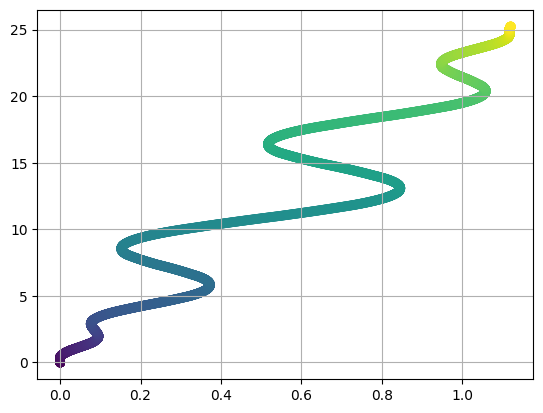

In [68]:
# plot vehicle path, looks like it matches the shape of the path taken during the experiment :)
plt.scatter(-df2['y_m'].values, df2['x_m'].values, c=df2.index)
plt.grid()


In [ ]:

from dataclasses import dataclass
from copy import deepcopy
from scipy.optimize import minimize

@dataclass
class VehicleBicycleModelParams:
    cf_Nprad: float = 0.0
    cr_Nprad: float = 0.0
    mass_kg: float = 0.0
    lf_m: float = 0.0
    lr_m: float = 0.0
    izz_kgm2: float = 0.0
    

class BicycleModelOptimizer:
    
    def __init__(self, init_vbm_params: VehicleBicycleModelParams):
        self.init_vbm_params = init_vbm_params
        self.vbm_params = deepcopy(init_vbm_params)
        
        # empty data fields for when the optimization happens
        self.times_s = None
        self.rwas_rad = None
        self.speeds_mps = None
        self.xs_actual = None
        self.ys_actual = None
        self.yrs_actual = None
        
    def get_a_b(self, vx_mps):
    
        vx_mps = max(vx_mps, 0.000001)
        cf_Nprad = self.vbm_params.cf_Nprad
        cr_Nprad = self.vbm_params.cr_Nprad
        mass_kg = self.vbm_params.mass_kg
        lf_m = self.vbm_params.lf_m
        lr_m = self.vbm_params.lr_m
        izz_kgm2 = self.vbm_params.izz_kgm2
        
        A = np.array([
            [ -(cf_Nprad + cr_Nprad) / (mass_kg * vx_mps), (cr_Nprad*lr_m - cf_Nprad*lf_m)/(mass_kg * vx_mps) - vx_mps ],
            [ (lr_m*cr_Nprad - lf_m*cf_Nprad) / (izz_kgm2*vx_mps), -(lf_m * lf_m * cf_Nprad + lr_m * lr_m * cr_Nprad)/(izz_kgm2*vx_mps) ]
        ])
        B = np.array([
            [cf_Nprad/mass_kg],
            [cf_Nprad*lf_m/izz_kgm2]
        ])
    
        return A, B
    
    def simulate_vbm(self, times_s, rwas_rad, speeds_mps):
        
        N = len(speeds_mps)
        dts = np.diff(times_s)
        state = np.array([[0.0],[0.0]]) # [vy, yaw_rate]'
        yaws_pred = np.zeros(N)
        xs_pred = np.zeros(N)
        ys_pred = np.zeros(N)
        yaw_rates_pred = np.zeros(N)
        ay_pred = np.zeros(N)
        
        for i in range(0, N-1):
        
            vx = speeds_mps[i]
            
            # get bm equations and step bm forward a timestep
            A, B = self.get_a_b(vx)
            state_dot = A @ state + B * rwas_rad[i]
            state += state_dot * dts[i]
            
            # get vx, vy, yaw rate, and update ego pose
            vy = state[0]
            yaw_rate = state[1]
            x_last = xs_pred[i]
            y_last = ys_pred[i]
            yaw_last = yaws_pred[i]
            
            dx = vx * dts[i]
            dy = vy * dts[i]
            dyaw = yaw_rate * dts[i]
            
            dx_prime = dx*np.cos(yaw_last) - dy*np.sin(yaw_last)
            dy_prime = dx*np.sin(yaw_last) + dy*np.cos(yaw_last)
            
            xs_pred[i+1] = x_last + dx_prime
            ys_pred[i+1] = y_last + dy_prime
            yaws_pred[i+1] = yaw_last + dyaw
            yaw_rates_pred[i+1] = yaw_rate
            ay_pred[i+1] = state_dot[0] + vx*yaw_rate
            
        return xs_pred, ys_pred, yaws_pred, yaw_rates_pred, ay_pred
    
    # THIS IS THE COST FUNCTION AND I CAN CHANGE MY WEIGHTS HERE :)))))
    def cost_function(self, actual_x, actual_y, actual_yr, predicted_x, predicted_y, predicted_yr):
        rmse_path = np.mean(np.sqrt(np.square(actual_x - predicted_x) + np.square(actual_y - predicted_y)))
        rmse_yawrate = np.sqrt(np.mean(np.square(actual_yr - predicted_yr)))
        return 0.05 * rmse_path + 10 * rmse_yawrate
    
    def simulate_and_get_cost(self, param_scalars):
        
        # update vbm params with newest guess
        self.vbm_params.cf_Nprad = param_scalars[0] * self.init_vbm_params.cf_Nprad
        self.vbm_params.cr_Nprad = param_scalars[1] * self.init_vbm_params.cr_Nprad
        self.vbm_params.mass_kg = param_scalars[2] * self.init_vbm_params.mass_kg
        self.vbm_params.izz_kgm2 = param_scalars[3] * self.init_vbm_params.izz_kgm2
        
        xs_pred, ys_pred, yaws_pred, yaw_rates_pred, ay_pred = self.simulate_vbm(self.times_s, self.rwas_rad, self.speeds_mps)
        cost = self.cost_function(self.xs_actual, self.ys_actual, self.yrs_actual, xs_pred, ys_pred, yaw_rates_pred)
        
        print(f'cost is {cost:.10f} for params {self.vbm_params}')
        
        return cost
    
    def optimize_vbm_params(self, times_s, rwas_rad, speeds_mps, xs_actual, ys_actual, yaws_actual, yrs_actual):
        param_scalars = [1, 1, 1, 1]
        param_scalar_bounds = [[0.7, 1.3], [0.7, 1.3], [0.7, 1.3], [0.7, 1.3]]
        
        self.times_s = times_s
        self.rwas_rad = rwas_rad
        self.speeds_mps = speeds_mps
        self.xs_actual = xs_actual
        self.ys_actual = ys_actual
        self.yrs_actual = yrs_actual
        
        solution = minimize(
            self.simulate_and_get_cost,
            param_scalars,
            bounds=param_scalar_bounds,
            method='Powell'
        )
        best_param_scalars = solution.x

        self.vbm_params.cf_Nprad = best_param_scalars[0] * self.init_vbm_params.cf_Nprad
        self.vbm_params.cr_Nprad = best_param_scalars[1] * self.init_vbm_params.cr_Nprad
        self.vbm_params.mass_kg = best_param_scalars[2] * self.init_vbm_params.mass_kg
        self.vbm_params.izz_kgm2 = best_param_scalars[3] * self.init_vbm_params.izz_kgm2
        
        print(f'best params: {self.vbm_params}')


In [70]:

# Actual values for vehicle model params
# 'C_Sf': 4.718, 'C_Sr': 5.4562, 'lf': 0.15875, 'lr': 0.17145, 'm': 3.74, 'I': 0.04712

# guess params close to the actual values to see what the behavior will look like
# lf and lr are exact since those are easily measurable and will not change
params = VehicleBicycleModelParams(
    5.0, 5.0, 3.0, 0.15875, 0.17145, 0.05
)
params = VehicleBicycleModelParams(
    4.718, 5.4562, 3.74, 0.15875, 0.17145, 0.04712
)

vmb = BicycleModelOptimizer(params)
times = df2.index.values.astype(np.int64) / 1.0e9
rwas = df2['rwa_rad'].values
speeds = df2['speed_mps'].values

xs, ys, yrs, ays = vmb.simulate_vbm(times, rwas, speeds)


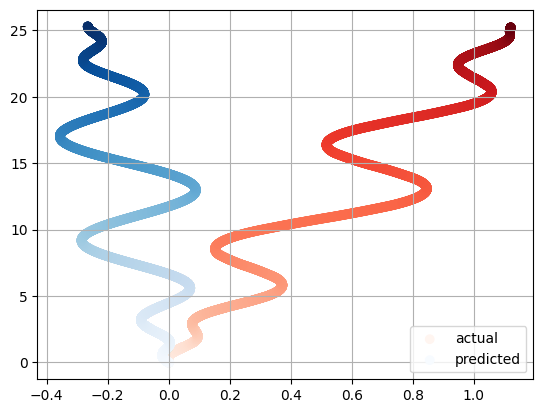

In [71]:
# similar profile, but not exactly the same
plt.scatter(-df2['y_m'].values, df2['x_m'].values, c=df2.index, cmap='Reds', label='actual')
plt.scatter(-ys, xs, c=xs, cmap='Blues', label='predicted')
plt.grid()
plt.legend()


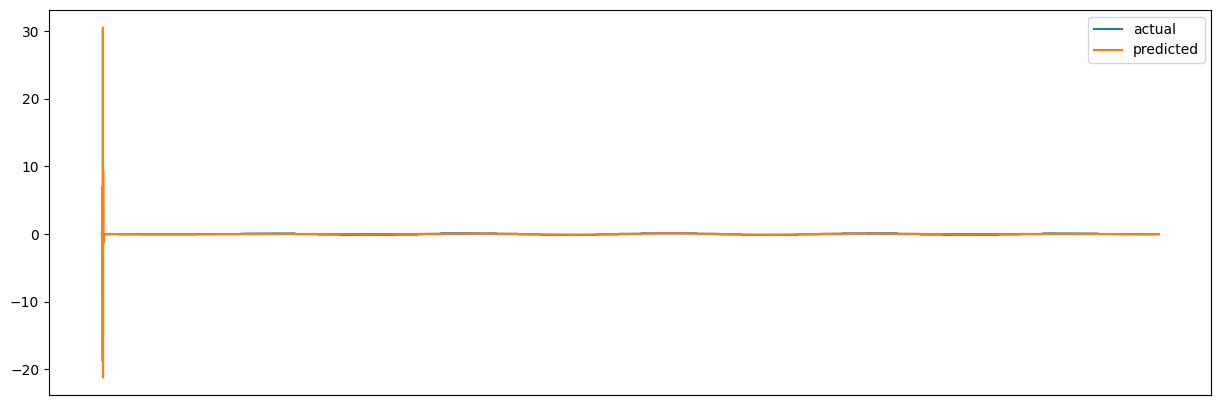

In [72]:
# profiles almost match up but not exactly
plt.plot(df2['yawrate_radps'], label='actual')
plt.plot(df2.index, yrs, label='predicted')
plt.gcf().set_size_inches(15, 5)
plt.legend()


In [73]:
vmb.optimize_vbm_params(times, rwas, speeds, df2['x_m'].values, df2['y_m'].values, df2['yawrate_radps'].values)


cost is 6.0033026501 for params VehicleBicycleModelParams(cf_Nprad=4.718, cr_Nprad=5.4562, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
cost is 4.6961098589 for params VehicleBicycleModelParams(cf_Nprad=4.383869384646798, cr_Nprad=5.4562, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
cost is 7.6693818539 for params VehicleBicycleModelParams(cf_Nprad=5.052130615353202, cr_Nprad=5.4562, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
cost is 3.4619868849 for params VehicleBicycleModelParams(cf_Nprad=3.970861230706405, cr_Nprad=5.4562, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
cost is 2.8645757734 for params VehicleBicycleModelParams(cf_Nprad=3.7156081539403925, cr_Nprad=5.4562, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
cost is 2.5469700464 for params VehicleBicycleModelParams(cf_Nprad=3.5578530767660115, cr_Nprad=5.4562, mass_kg=3.74, lf_m=0.15875, lr_m=0.17145, izz_kgm2=0.04712)
cost is 2.3681170674 for params 

(-3.0, 3.0)

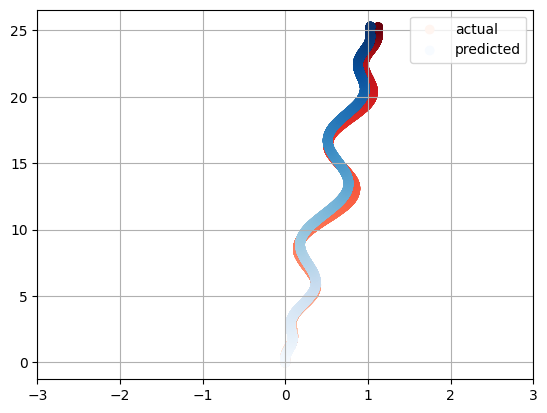

In [74]:
xs, ys, yrs, ays = vmb.simulate_vbm(times, rwas, speeds)
plt.scatter(-df2['y_m'].values, df2['x_m'].values, c=df2.index, cmap='Reds', label='actual')
plt.scatter(-ys, xs, c=xs, cmap='Blues', label='predicted')
plt.grid()
plt.legend()
plt.xlim(-3, 3)


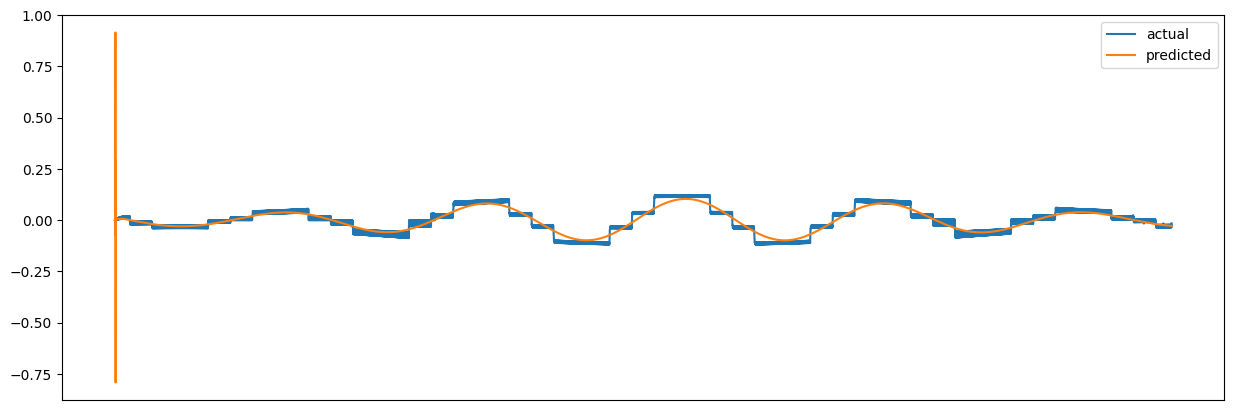

In [75]:
plt.plot(df2['yawrate_radps'], label='actual')
plt.plot(df2.index, yrs, label='predicted')
plt.gcf().set_size_inches(15, 5)
plt.legend()


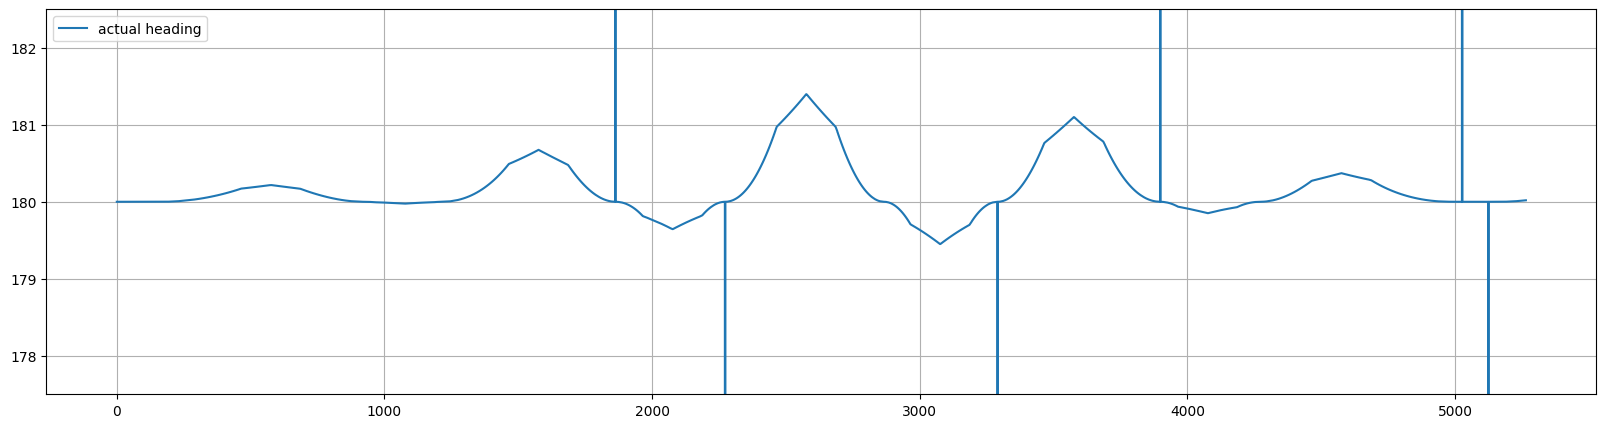

In [77]:
plt.plot(np.mod(df2['heading_deg'].values + 180, 360), label='actual heading')
plt.ylim(177.5, 182.5)
plt.gcf().set_size_inches(20, 5)
plt.legend()
plt.grid()


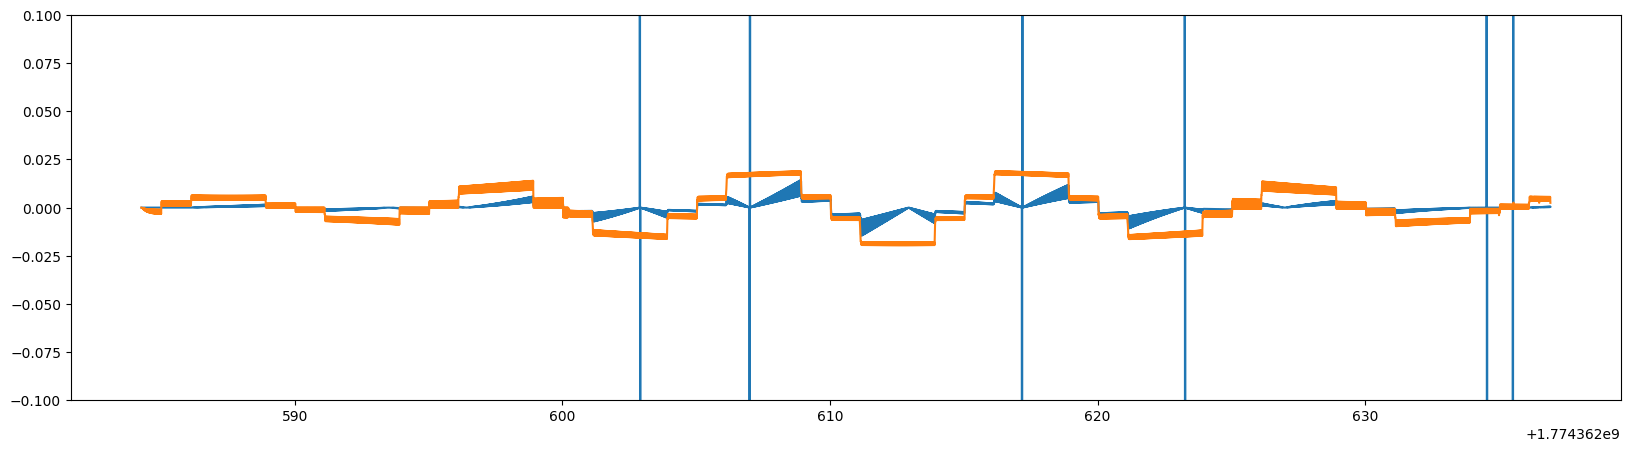

In [63]:

plt.plot(times[1:], np.diff(np.mod(df2['heading_deg'].values + 180, 360)), label='actual heading')
plt.plot(times, df2['yawrate_radps'].values / (-2*3.14), label='measured yaw rate')
plt.ylim(-0.1, 0.1)
plt.gcf().set_size_inches(20, 5)
